In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/earthquake-dataset/earthquake_data.csv
/kaggle/input/earthquake-dataset/earthquake_1995-2023.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# title: title name given to the earthquake
# magnitude: The magnitude of the earthquake
# date_time: date and time
# cdi: The maximum reported intensity for the event range
# mmi: The maximum estimated instrumental intensity for the event
# alert: The alert level - “green”, “yellow”, “orange”, and “red”
# tsunami: "1" for events in oceanic regions and "0" otherwise
# sig: A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact
# net: The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.
# nst: The total number of seismic stations used to determine earthquake location.
# dmin: Horizontal distance from the epicenter to the nearest station
# gap: The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties
# magType: The method or algorithm used to calculate the preferred magnitude for the event
# depth: The depth where the earthquake begins to rupture
# latitude / longitude: coordinate system by means of which the position or location of any place on Earth's surface can be determined and described
# location: location within the country
# continent: continent of the earthquake hit country
# country: affected country

In [4]:
df=pd.read_csv('/kaggle/input/earthquake-dataset/earthquake_data.csv')

# INFO

In [5]:
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      782 non-null    object 
 1   magnitude  782 non-null    float64
 2   date_time  782 non-null    object 
 3   cdi        782 non-null    int64  
 4   mmi        782 non-null    int64  
 5   alert      415 non-null    object 
 6   tsunami    782 non-null    int64  
 7   sig        782 non-null    int64  
 8   net        782 non-null    object 
 9   nst        782 non-null    int64  
 10  dmin       782 non-null    float64
 11  gap        782 non-null    float64
 12  magType    782 non-null    object 
 13  depth      782 non-null    float64
 14  latitude   782 non-null    float64
 15  longitude  782 non-null    float64
 16  location   777 non-null    object 
 17  continent  206 non-null    object 
 18  country    484 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 1

In [7]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,0.388747,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199
std,0.445514,3.169939,1.462724,0.487778,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886
min,6.500000,0.000000,1.000000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.000000,0.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050
50%,6.800000,5.000000,6.000000,0.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000
75%,7.100000,7.000000,7.000000,1.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000
max,9.100000,9.000000,9.000000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


In [8]:
nill=round(df.isnull().sum()/df.shape[0]*100,2)
nill[nill>0.1]
#continent,country,alert have 73%,38%,46% null values
#we can drop continenet(too much null values)
#we have latitude and longitude so we can drop location
#alert is a unnecessary data

alert        46.93
location      0.64
continent    73.66
country      38.11
dtype: float64

In [9]:
df.columns

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

# DROPING UNNECESSARY COLUMNS

In [10]:
df.drop(['title', 'continent', 'alert','location'],axis=1,inplace=True)

In [11]:
#Converting date_time to year and month
df['date_time']=pd.to_datetime(df['date_time'])
df['Year']=pd.DatetimeIndex(df["date_time"]).year
df['Month']=pd.DatetimeIndex(df["date_time"]).month
df.drop('date_time',axis=1,inplace=True)

In [12]:
df.head()

,magnitude,cdi,mmi,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,country,Year,Month
0,7.0,8,7,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,Solomon Islands,2022,11
1,6.9,4,4,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,NaN,2022,11
2,7.0,3,3,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,Fiji,2022,12
3,7.3,5,5,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,NaN,2022,11
4,6.6,0,2,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,2022,9


In [13]:
df.isnull().sum()

magnitude      0
cdi            0
mmi            0
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
country      298
Year           0
Month          0
dtype: int64

# EDA

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

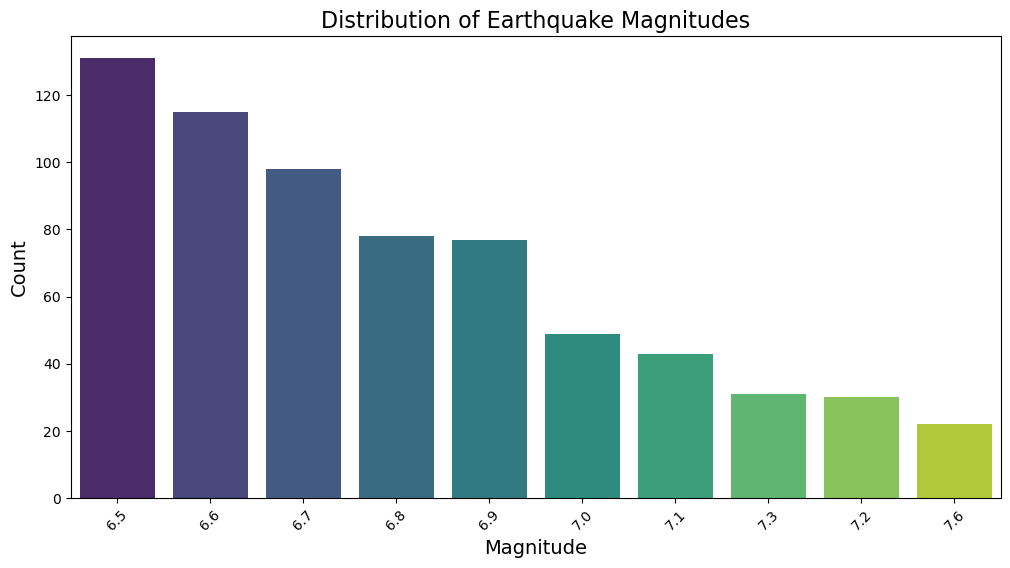

In [15]:
M_order=df['magnitude'].value_counts().head(10).index 

plt.figure(figsize=(12, 6))
sns.countplot(x='magnitude', data=df, palette='viridis',order=M_order)
plt.title('Distribution of Earthquake Magnitudes', fontsize=16)
plt.xlabel('Magnitude', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()
#Most earthquakes tend to be around 6.5 to 6.7 on the scale

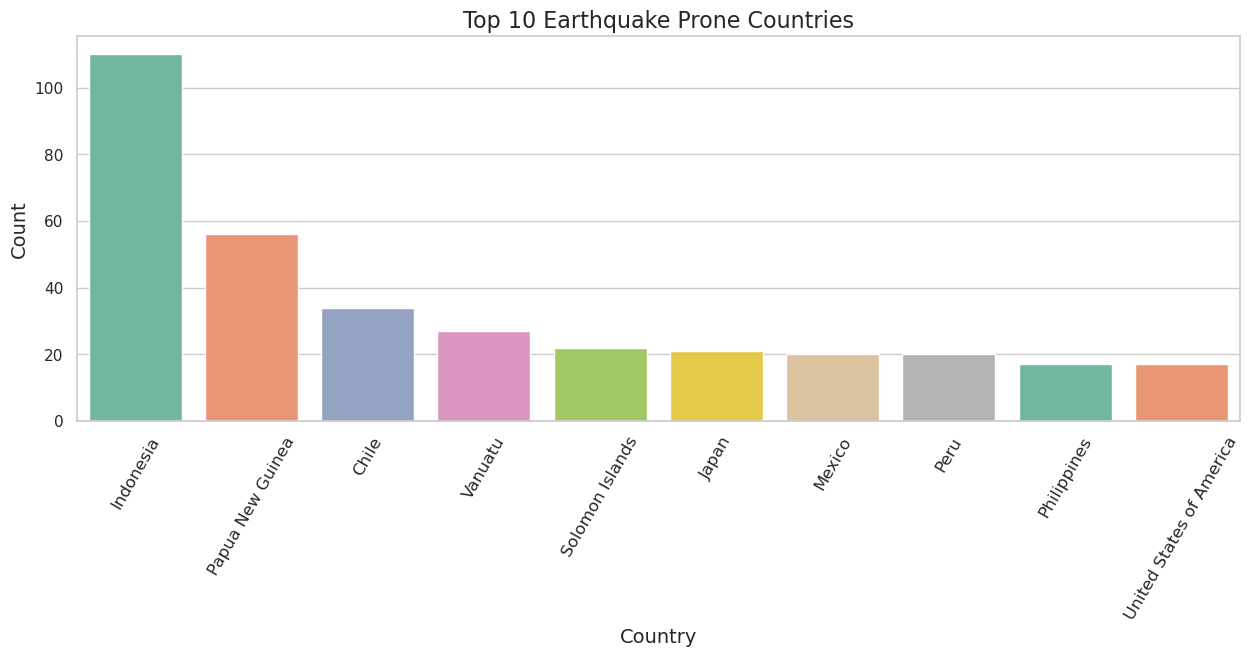

In [16]:
c_order = df['country'].value_counts().head(10).index

plt.figure(figsize=(15, 5))

sns.set(style="whitegrid")
sns.countplot(x='country', data=df, order=c_order, palette='Set2')
plt.xticks(rotation=60, fontsize=12)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Top 10 Earthquake Prone Countries', fontsize=16)
plt.show()


#Indonesia faced the highest number of earthquakes.

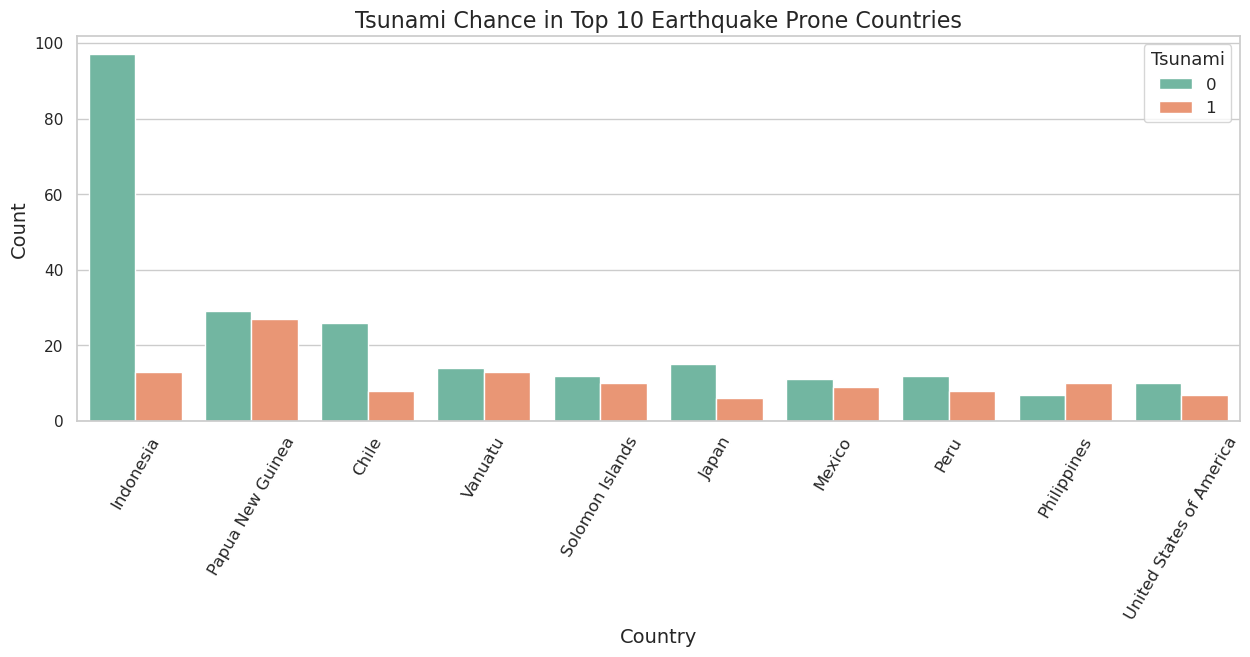

In [17]:
c_order = df['country'].value_counts().head(10).index

plt.figure(figsize=(15, 5))

sns.set(style="whitegrid")

sns.countplot(x='country', data=df, order=c_order, hue='tsunami', palette='Set2')

plt.xticks(rotation=60, fontsize=12)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Tsunami Chance in Top 10 Earthquake Prone Countries', fontsize=16)
plt.legend(title='Tsunami', title_fontsize='13', fontsize='12')
#Indonesia has the highest number of earthquakes worldwide, but Papua New Guinea and Philippines  has a very high risk of tsunamis following an earthquake.

In [18]:
country_count = df.groupby('country')['tsunami'].value_counts().unstack(fill_value=0)
country_count.columns = ['No Tsunami', 'Tsunami']
country_count['Earthquick']=country_count['No Tsunami']+country_count['Tsunami']
country_count['Tsunami Probability']=round((country_count['Tsunami']/country_count['Earthquick'])*100,2)

# Filter out countries with a minimum number of earthquakes
threshold = 5
filtered_country=country_count[country_count['Earthquick']>threshold]
top_15_tsunami_countries=filtered_country.sort_values(by='Tsunami Probability',ascending=False).head(15)
print(top_15_tsunami_countries[['Tsunami Probability', 'Earthquick']])




                          Tsunami Probability  Earthquick
country                                                  
Fiji                                    88.89           9
Ecuador                                 66.67           6
Philippines                             58.82          17
New Zealand                             55.56           9
Taiwan                                  50.00           6
Papua New Guinea                        48.21          56
Vanuatu                                 48.15          27
Solomon Islands                         45.45          22
Mexico                                  45.00          20
United States of America                41.18          17
Peru                                    40.00          20
Russia                                  33.33          15
Japan                                   28.57          21
Chile                                   23.53          34
Indonesia                               11.82         110


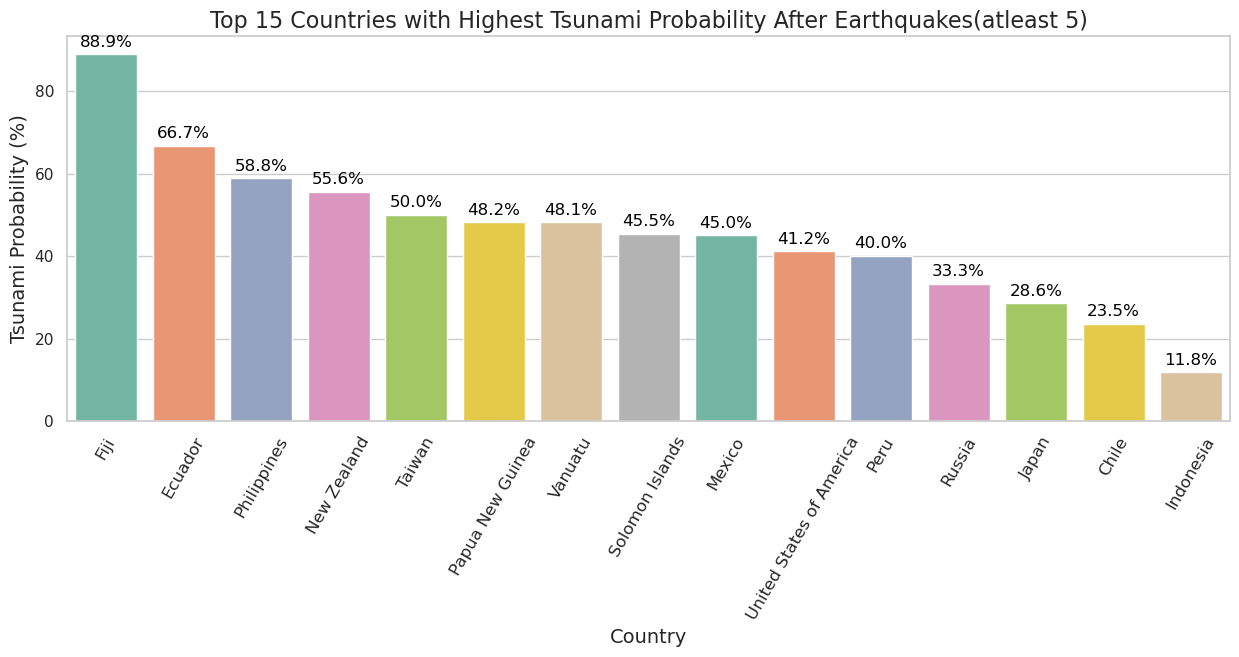

In [19]:
plt.figure(figsize=(15, 5))
ax=sns.barplot(x=top_15_tsunami_countries.index, y=top_15_tsunami_countries['Tsunami Probability'], palette='Set2')
plt.xticks(rotation=60, fontsize=12)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Tsunami Probability (%)', fontsize=14)
plt.title('Top 15 Countries with Highest Tsunami Probability After Earthquakes(atleast 5)', fontsize=16)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()+3),
                ha='center', va='center',fontsize=12, color='black')


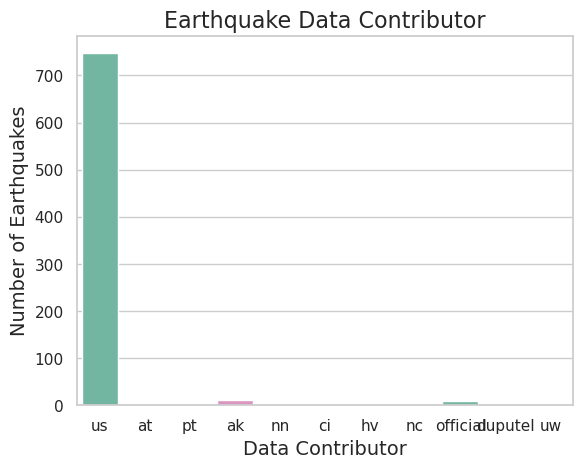

In [20]:
sns.countplot(x='net',data=df,palette='Set2')
plt.title('Earthquake Data Contributor', fontsize=16)
plt.xlabel('Data Contributor', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)
#The US is a major contributor of earthquake data
plt.show()

Text(0, 0.5, 'Count')

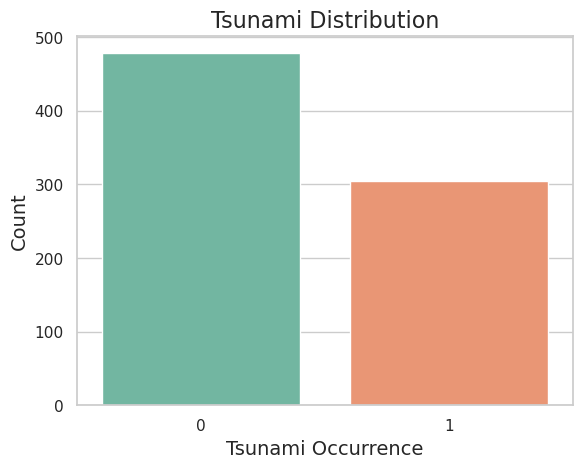

In [21]:
sns.countplot(x='tsunami', data=df, palette='Set2')

plt.title('Tsunami Distribution', fontsize=16)
plt.xlabel('Tsunami Occurrence', fontsize=14)
plt.ylabel('Count', fontsize=14)

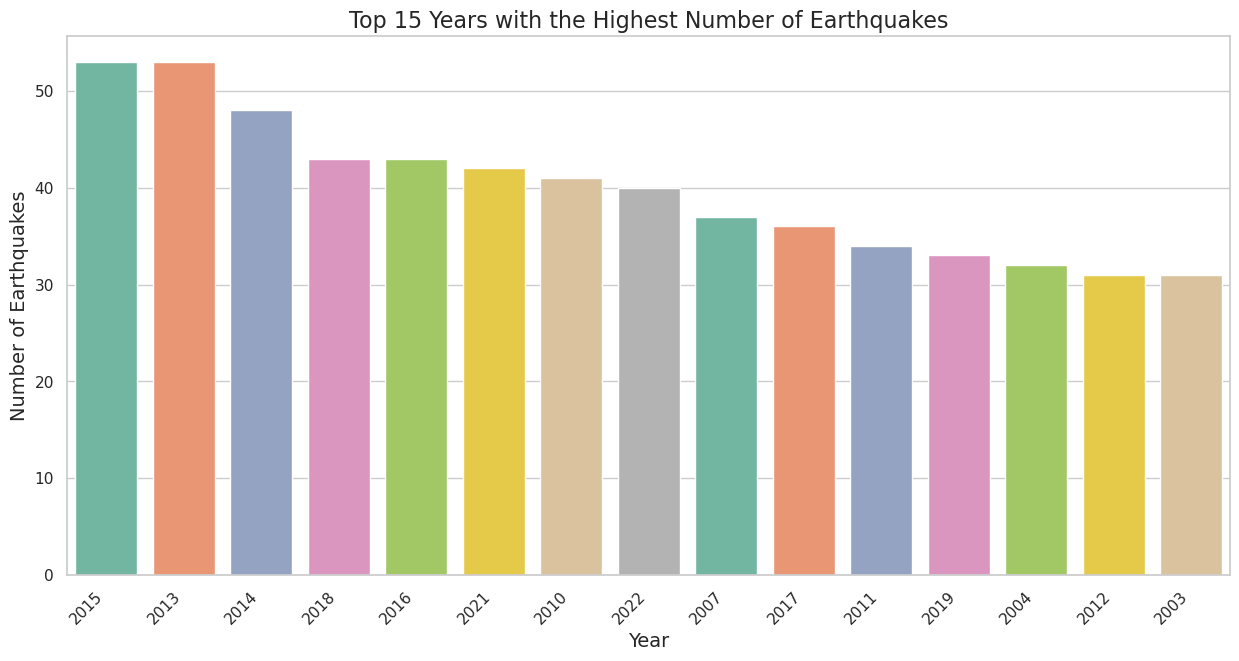

In [22]:
plt.figure(figsize=(15, 7))

top_years = df['Year'].value_counts().head(15).index
sns.countplot(x='Year', data=df, order=top_years, palette='Set2')
plt.title('Top 15 Years with the Highest Number of Earthquakes', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.show()
#In 2015 and 2013, the world experienced the highest number of earthquakes. 

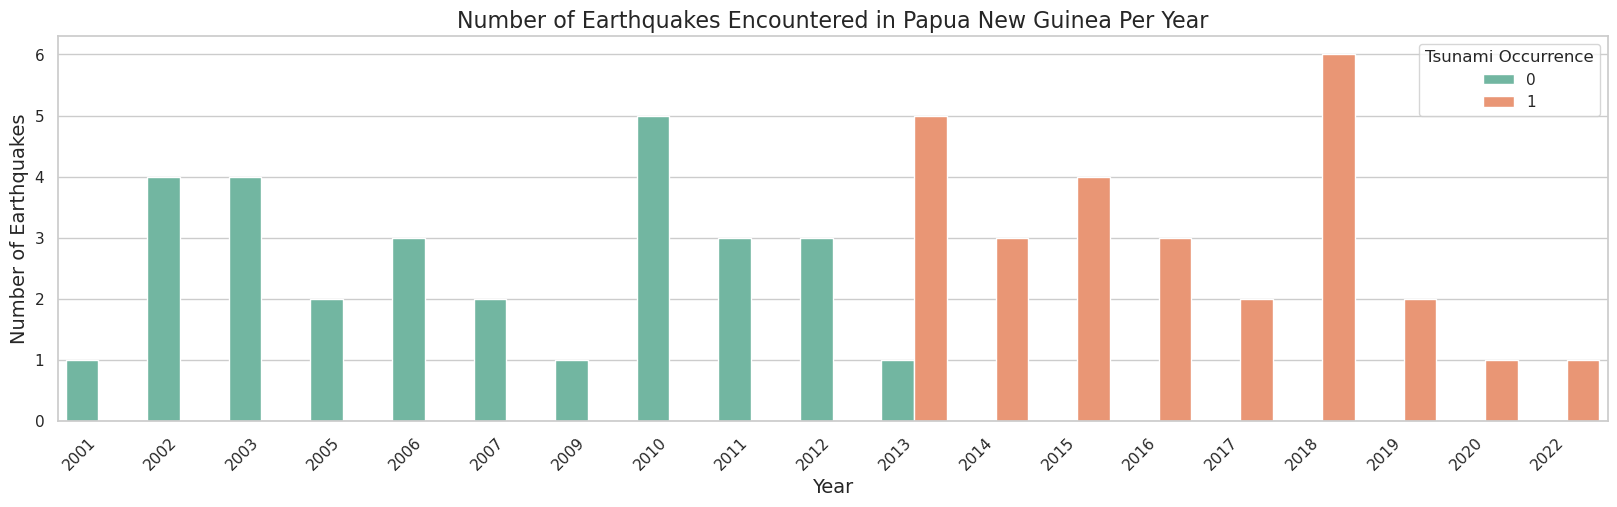

In [23]:
Papua=df[df['country']=='Papua New Guinea']

plt.figure(figsize=(20, 5))
sns.countplot(x='Year', data=Papua, hue='tsunami', palette='Set2')

plt.title('Number of Earthquakes Encountered in Papua New Guinea Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.legend(title='Tsunami Occurrence')
#Papua New Guinea experiences at least one earthquake per year but before 2013 Papua New Guinea never experienced tsunami after earthquick 

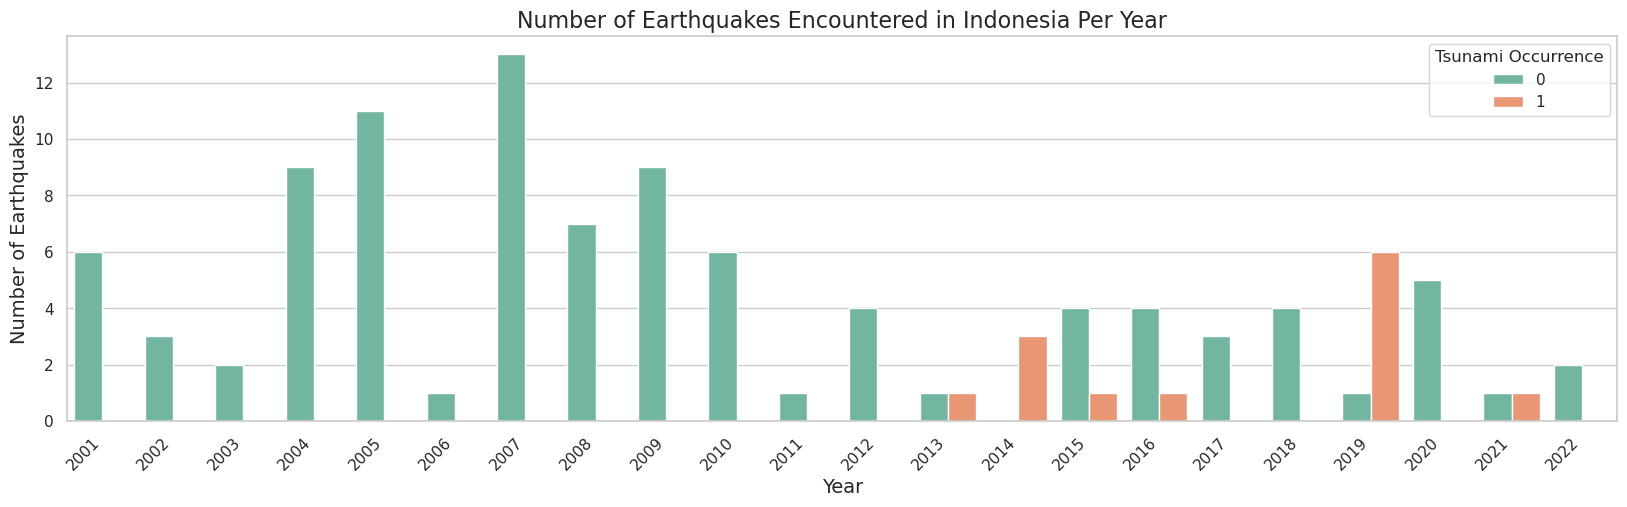

In [24]:
Indo = df[df['country'] == 'Indonesia']
plt.figure(figsize=(20, 5))
sns.countplot(x='Year', data=Indo, hue='tsunami', palette='Set2')
plt.title('Number of Earthquakes Encountered in Indonesia Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tsunami Occurrence')
plt.show()
#Indonesia encountered 13 earthquic in the year 2007

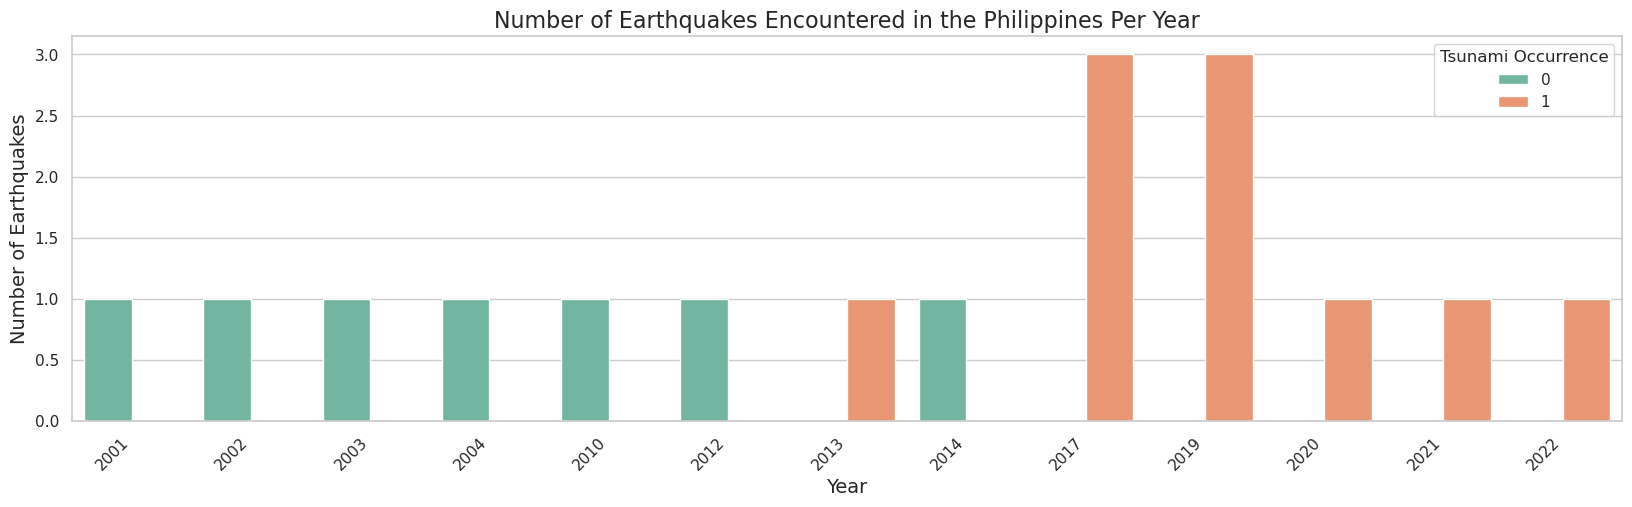

In [25]:

Phi = df[df['country'] == 'Philippines']
plt.figure(figsize=(20, 5))
sns.countplot(x='Year', data=Phi, hue='tsunami', palette='Set2')
plt.title('Number of Earthquakes Encountered in the Philippines Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tsunami Occurrence')
plt.show()
# The Philippines has experienced all of tsunamis in recent years(After 2013) following earthquakes.

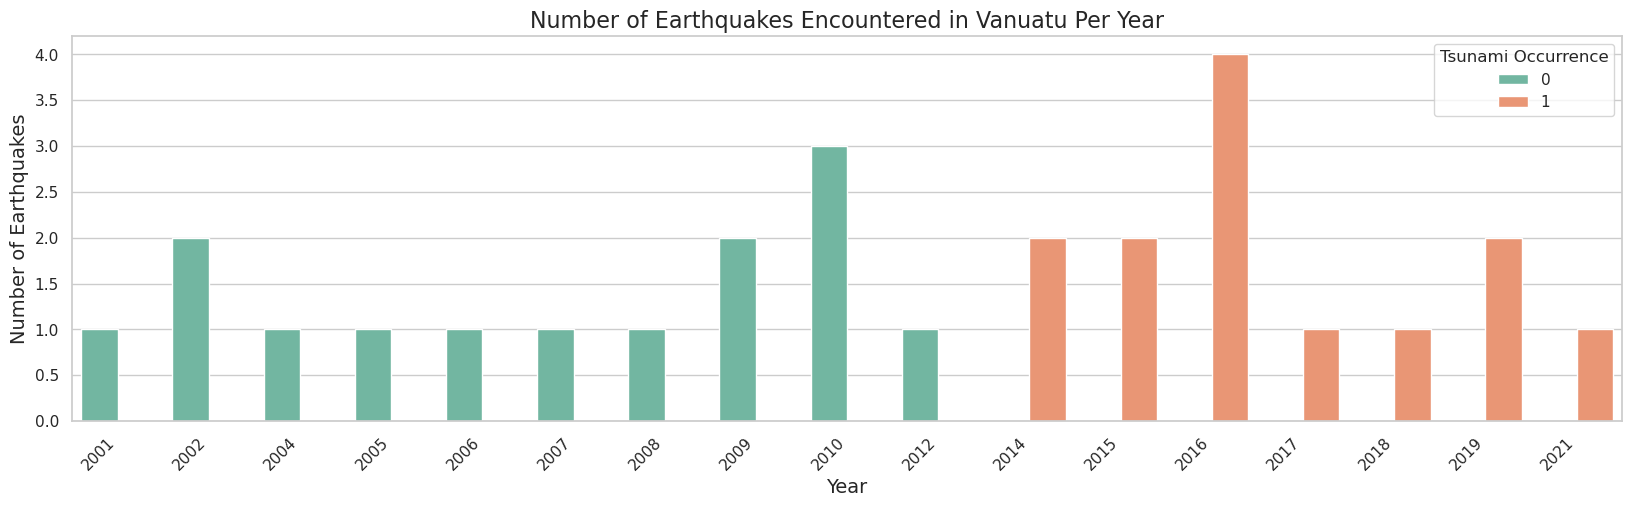

In [26]:
Van = df[df['country'] == 'Vanuatu']
plt.figure(figsize=(20, 5))
sns.countplot(x='Year', data=Van, hue='tsunami', palette='Set2')
plt.title('Number of Earthquakes Encountered in Vanuatu Per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Earthquakes', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tsunami Occurrence')
plt.show()

### Note:
## After examining the countries most affected by tsunamis, we can conclude that there has been a significant change in climate. Most earthquake-prone countries are facing a greater chance of tsunamis following earthquakes, especially after 2013.

# FEATURE ENGINEERING

In [27]:
df.head()

,magnitude,cdi,mmi,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,country,Year,Month
0,7.0,8,7,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,Solomon Islands,2022,11
1,6.9,4,4,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,NaN,2022,11
2,7.0,3,3,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,Fiji,2022,12
3,7.3,5,5,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,NaN,2022,11
4,6.6,0,2,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,2022,9


In [28]:
df.drop('country',axis=1,inplace=True)#we have latitude and longitude

In [29]:
obj=df.select_dtypes(include=['object'])
obj
#we can drop net because 95% of data contributed by US 

,net,magType
0,us,mww
1,us,mww
2,us,mww
3,us,mww
4,us,mww
...,...,...
777,us,mwc
778,ak,mw
779,us,mwb
780,us,mwc


In [30]:
obj.nunique()

net        11
magType     9
dtype: int64

In [31]:
obj.drop('net',axis=1,inplace=True)
df.drop(['net','magType'],axis=1,inplace=True)
from sklearn.preprocessing import LabelEncoder
lr=LabelEncoder()
obj_lbl=obj.apply(lr.fit_transform)
df=pd.concat([df,obj_lbl],axis=1)
df.head()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,magType
0,7.0,8,7,1,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,8
1,6.9,4,4,0,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,8
2,7.0,3,3,1,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,12,8
3,7.3,5,5,1,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,8
4,6.6,0,2,1,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,9,8


<Axes: >

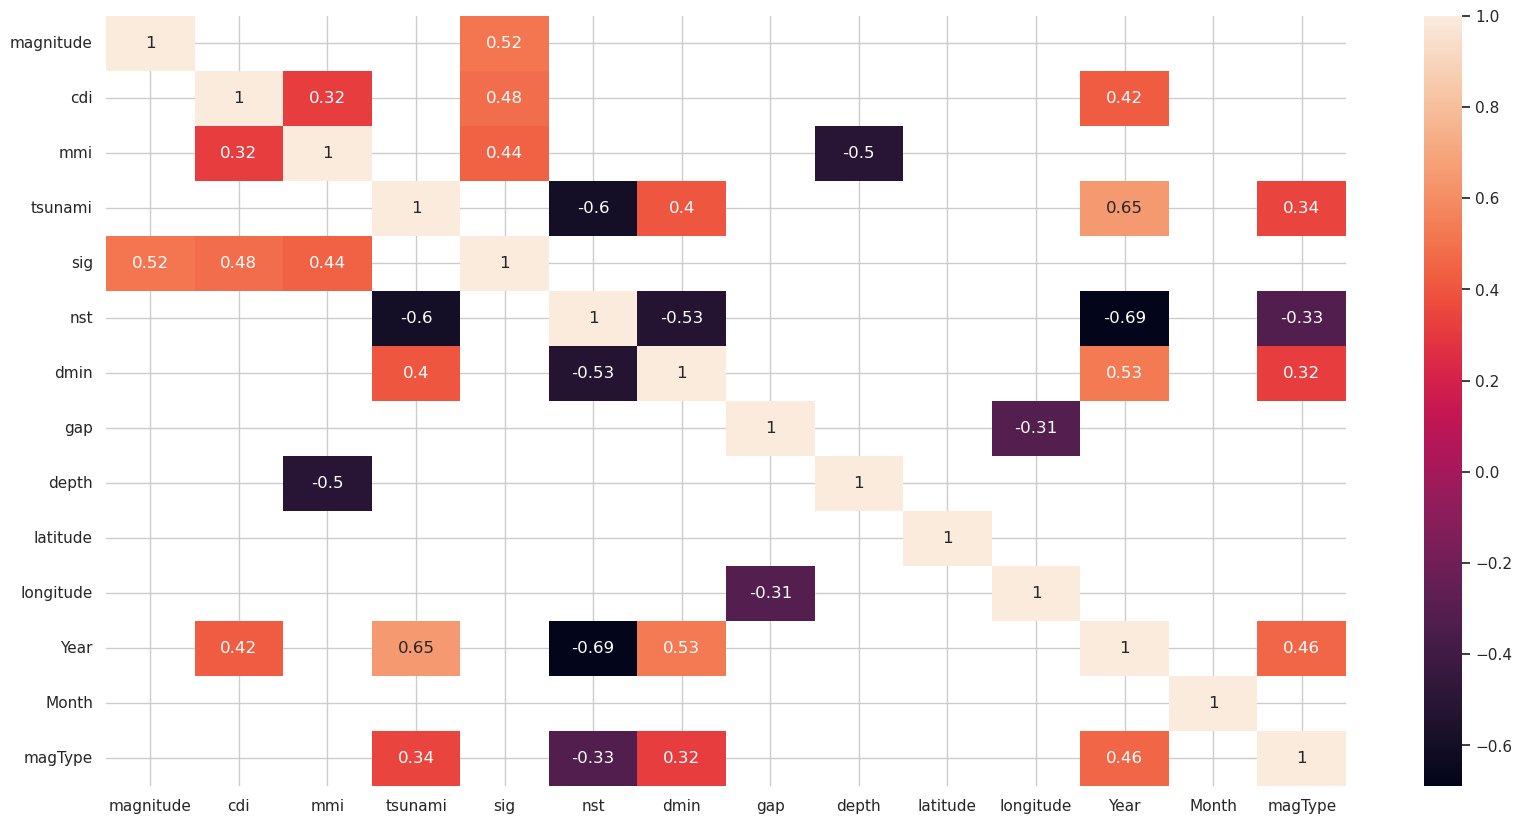

In [32]:
d=df.corr()
d=d[(d>0.3) | (d<-0.3)]
plt.figure(figsize=(20,10))
sns.heatmap(d,annot=True)

# SCALING AND MODEL BUILDING

## Logistic Regression vs Linear Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler,SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import xgboost as xgb

In [34]:
sc=StandardScaler()
x=df.drop('tsunami',axis=1)
y=df['tsunami']
x_scaled=sc.fit_transform(x)
x=pd.DataFrame(x_scaled,columns=x.columns)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [35]:

sc = StandardScaler()

x=df.drop('tsunami',axis=1)
y=df['tsunami']
x_scaled=sc.fit_transform(x)
x=pd.DataFrame(x_scaled,columns=x.columns)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

<Axes: xlabel='tsunami', ylabel='count'>

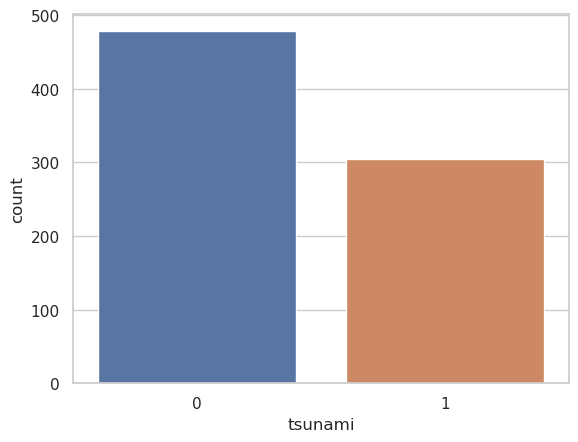

In [36]:
sns.countplot(x=y,data=df)

# DEALING WITH IMBALANCE DATA

In [37]:
sm=SMOTE()
x_train,y_train=sm.fit_resample(x_train,y_train)

In [38]:
x_train.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,magType
0,-0.092369,0.525974,-1.343693,-0.422358,-0.920899,3.173666,0.948427,-0.431398,-2.269280,-0.644532,1.430546,0.334697,0.589322
1,-0.990783,-1.368018,0.024494,-0.683018,0.342959,-0.597892,-1.034260,-0.378187,0.369710,-1.216932,-1.522433,-1.696490,-0.378850
2,-0.316972,0.210309,-0.659599,-0.487523,1.282853,-0.597892,0.047957,0.540252,-0.708646,0.977562,-1.030270,0.044527,-1.347022
3,0.356838,0.210309,0.708588,-0.279616,0.586931,-0.597892,-0.414670,-0.480236,-0.451554,0.888998,-0.374052,-1.116151,-0.378850
4,1.704459,1.157305,2.076775,0.579941,-0.920899,-0.133832,0.783203,-0.389850,-0.883568,-1.044803,0.282165,-1.116151,0.589322


In [39]:
models = {
    "Logistic regression":LogisticRegression(),
    "Linear Regression": LinearRegression(),
}

# RESULT

In [40]:
for name, model in models.items():
    model.fit(x_train, y_train)
    raw_pred = model.predict(x_test)

    # convert continuous outputs from LinearRegression to binary labels
    if isinstance(model, LinearRegression) or name.lower().startswith('linear'):
        p = (raw_pred >= 0.5).astype(int)
    else:
        p = raw_pred

    print("Model: " , name)
    print("------------------------------")
    print(classification_report(y_test, p))
    print(".........................................................|")

Model:  Logistic regression
------------------------------
              precision    recall  f1-score   support

           0       0.93      0.80      0.86        88
           1       0.78      0.93      0.85        69

    accuracy                           0.85       157
   macro avg       0.86      0.86      0.85       157
weighted avg       0.87      0.85      0.85       157

.........................................................|
Model:  Linear Regression
------------------------------
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        88
           1       0.77      0.94      0.85        69

    accuracy                           0.85       157
   macro avg       0.86      0.86      0.85       157
weighted avg       0.87      0.85      0.85       157

.........................................................|


- Interpretation / conclusions
  - Both models perform nearly identically on main metrics (accuracy and f1). LinearRegression forced into classification (thresholding) yields results very similar to LogisticRegression after SMOTE.
  - LogisticRegression is preferable conceptually for classification because it provides calibrated probabilities and is designed for binary classification; LinearRegression was adapted by thresholding.
  - Both models show a trade-off: very high precision for class 0 and very high recall for class 1 — the models are good at detecting tsunami events (high recall for class 1) but produce some false positives (precision ~0.71–0.72).

- Short recommendations / next steps
  - Prefer LogisticRegression for interpretability and calibrated probabilities; use ensemble models (RandomForest / XGBoost) if higher accuracy is the priority (they previously performed better).
  - Further evaluation: compute ROC-AUC, precision–recall curve, and run cross-validation to check metric stability.
  - Consider probability calibration, and tune decision threshold according to the cost of false negatives vs false positives.
  - Inspect feature importances / coefficients and apply feature selection if needed.